In [2]:
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt


In [ ]:
# CARICO PM100 (parquet) -> pandas E STAMPO INFO
# NB Usare job:bes_opt che serve una versione veccha per usare parquet

# import pandas as pd
# pm = pd.read_parquet("datasets/job_table.parquet")
# # Esplora colonne
# print(pm.columns)
# # Aggrega per intervallo temporale (es. resample a 1s/1min)
# pm['start'] = pd.to_datetime(pm['start_time'])
# pm['end'] = pd.to_datetime(pm['end_time'])
# pm.info()


# example = pm['node_power_consumption'].iloc[1]
# mem = pm['mem_power_consumption'].iloc[1]
# cpu = pm['cpu_power_consumption'].iloc[1]
# print(example)
# print(mem)
# print(cpu)
# len(example)
# duration = (pm['end'] - pm['start']).dt.total_seconds().iloc[1]

# print("samples:", len(example))
# print("duration (s):", duration)
# print("sample interval (s):", duration / len(example))


Index(['cores_alloc_layout', 'cores_allocated', 'cores_per_task', 'derived_ec',
       'eligible_time', 'end_time', 'group_id', 'job_id', 'job_state', 'nodes',
       'num_cores_req', 'num_cores_alloc', 'num_nodes_req', 'num_nodes_alloc',
       'num_tasks', 'partition', 'priority', 'qos', 'req_nodes', 'req_switch',
       'run_time', 'shared', 'start_time', 'state_reason', 'submit_time',
       'threads_per_core', 'time_limit', 'num_gpus_req', 'num_gpus_alloc',
       'mem_req', 'mem_alloc', 'user_id', 'node_power_consumption',
       'mem_power_consumption', 'cpu_power_consumption'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231238 entries, 0 to 231237
Data columns (total 37 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   cores_alloc_layout      231238 non-null  object             
 1   cores_allocated         231238 non-null  object             
 2   cores

In [ ]:
# # DAL PM100 CREO L'ANDAMENTO DELLA POTENZA RICHEISTA DEL CLUSTER SCANDITA OGNI 20 SECONDI
# utilizzando le 3 poerr consumption - non credo abbia senso

# def resample_list(values, N):
#     """Resample a list to length N using linear interpolation.
#        If the list is empty, return zeros."""
#     if len(values) == 0:
#         return np.zeros(N)
#     if len(values) == 1:
#         # se solo 1 valore → replica
#         return np.ones(N) * float(values[0])

#     values = np.array(values, dtype=float)
#     x_old = np.linspace(0, 1, len(values))
#     x_new = np.linspace(0, 1, N)
#     return np.interp(x_new, x_old, values)


# pm = pd.read_parquet("datasets/job_table.parquet")
# pm['start'] = pd.to_datetime(pm['start_time'])
# pm['end']   = pd.to_datetime(pm['end_time'])

# step = pd.Timedelta(seconds=20)

# rows = []

# for _, row in pm.iterrows():

#     start = row['start']
#     end   = row['end']

#     L_node = len(row['node_power_consumption'])
#     L_mem  = len(row['mem_power_consumption'])
#     L_cpu  = len(row['cpu_power_consumption'])

#     N = max(L_node, L_mem, L_cpu, 1)   # almeno 1

#     node = resample_list(row['node_power_consumption'], N)
#     mem  = resample_list(row['mem_power_consumption'],  N)
#     cpu  = resample_list(row['cpu_power_consumption'],  N)

#     t = pd.date_range(start=start, end=end, periods=N)

#     p = node #+ mem + cpu

#     rows.append(pd.DataFrame({"time": t, "power": p}))

# df_all = pd.concat(rows)

# df_cluster = (
#     df_all
#     .set_index("time")
#     .resample(step)
#     .sum()
# )

# df_cluster.to_csv("cluster_power.csv")
# print(df_cluster.head())



                                 power
time                                  
2020-05-05 15:56:00+00:00  1402.000000
2020-05-05 15:56:20+00:00  1435.934025
2020-05-05 15:56:40+00:00  1496.307886
2020-05-05 15:57:00+00:00     0.000000
2020-05-05 15:57:20+00:00  1559.736098


In [ ]:
# # Stessa cosa di prima ma usando solo i job consumtpion  per node

# def resample_list(values, N):
#     """Resample a list to length N using linear interpolation.
#        If empty → zeros, if length=1 → replicate."""
#     values = list(values)
    
#     if len(values) == 0:
#         return np.zeros(N)
#     if len(values) == 1:
#         return np.ones(N) * float(values[0])

#     values = np.array(values, dtype=float)
#     x_old = np.linspace(0, 1, len(values))
#     x_new = np.linspace(0, 1, N)
#     return np.interp(x_new, x_old, values)

# # Caricamento dataset
# pm = pd.read_parquet("datasets/job_table.parquet")
# pm['start'] = pd.to_datetime(pm['start_time'])
# pm['end']   = pd.to_datetime(pm['end_time'])

# step = pd.Timedelta(seconds=20)

# rows = []

# for _, row in pm.iterrows():

#     start = row['start']
#     end   = row['end']

#     # Lunghezza della serie node_power_consumption
#     L_node = len(row['node_power_consumption'])

#     # N minimo = max(L_node, 1)
#     N = max(L_node, 1)

#     # 🔥 usa solo node_power_consumption
#     node = resample_list(row['node_power_consumption'], N)

#     # timeline
#     t = pd.date_range(start=start, end=end, periods=N)

#     # DataFrame del job
#     rows.append(pd.DataFrame({"time": t, "power": node}))

# # Unisci tutto
# df_all = pd.concat(rows)

# # Resample cluster
# df_cluster = (
#     df_all
#     .set_index("time")
#     .resample(step)
#     .sum()
# )

# df_cluster.to_csv("cluster_power_only_nodes.csv")

# print(df_cluster.head())


                            power
time                             
2020-05-05 15:56:00+00:00  1280.0
2020-05-05 15:56:20+00:00  1310.0
2020-05-05 15:56:40+00:00  1240.0
2020-05-05 15:57:00+00:00     0.0
2020-05-05 15:57:20+00:00  1280.0


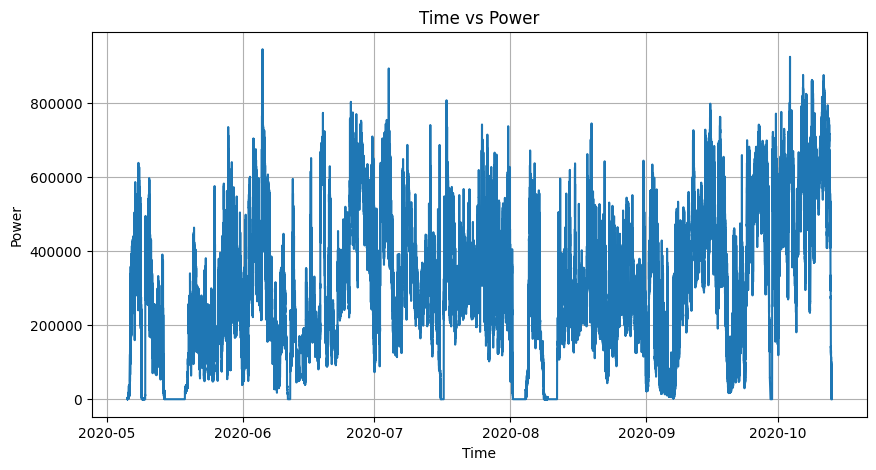

2020-05-05 15:56:00+00:00
2020-10-13 05:21:40+00:00
693618


In [6]:
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt

df = pd.read_csv("csvs/cluster_power_only_nodes.csv")
df["time"] = pd.to_datetime(df["time"], utc=True)
plt.figure(figsize=(10, 5))
plt.plot(df["time"], df["power"])
plt.xlabel("Time")
plt.ylabel("Power")
plt.title("Time vs Power")
plt.grid(True)
plt.show()

print(df["time"][0])
print(df["time"].iloc[-1])
print(len(df)) 
# df_10days.to_csv("cluster_power_only_nodes_30days.csv", index=False)

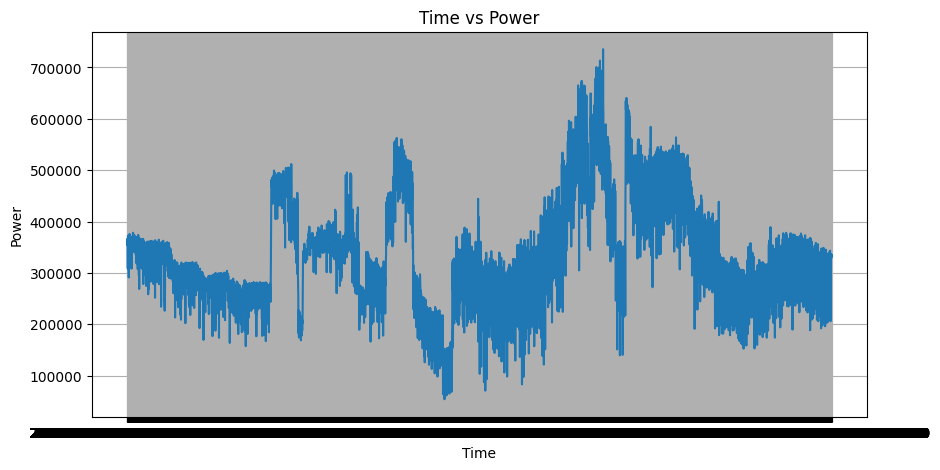

In [1]:
import pandas as pd
import scipy.io
import matplotlib.pyplot as plt
df = pd.read_csv("cluster_power_only_nodes_10days.csv")
df_first = df[8641:12960]
plt.figure(figsize=(10, 5))
plt.plot(df_first["time"], df_first["power"])
plt.xlabel("Time")
plt.ylabel("Power")
plt.title("Time vs Power")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
from utils.co2 import CarbonIntensityModels


# IN QUESTA SIMULAZIONE, NON ABBIAMO UNA BATTERIA
# valutiamo dunque il costo complessivo senza avere una batteria e avendo una soglia max.
# SE SUPERIAMO LA SOGLIA DI RICHIESTA ALLA RETE ELETTRICA, PAGHIAMO TUTTO DI PIÙ (IL triplo)
def dynamic_low_price(timestamp):
    hour = timestamp.hour
    if 0 <= hour < 6:
        return 0.0005
    elif 6 <= hour < 22:
        return 0.0012
    else:
        return 0.0007


def compute_cost(row):

    # se supero la soglia, il prezzo è x3

    energy = row["energy_Wh"]
    power = row["power"]
    dt = row["dt_hours"]
    E_peak = (power - THRESHOLD) * dt 
    E_base = THRESHOLD * dt

    COST_LOW = row["price_base"]
    COST_HIGH = COST_LOW * 3

    if row["power"] <= THRESHOLD:
        cost =  COST_LOW * energy
    else:
        cost =  E_peak * COST_HIGH + E_base * COST_LOW
    

    # print('energy =', energy , 'power =', power , " dt = ", dt, 'costo = ', cost)
    # print(energy , ';', power , ";", dt, ';', cost)
    # print(cost)

    return cost


# Parametri costi
THRESHOLD = 400000          # Watt

# Carica il CSV (usa header già presente)
df = pd.read_csv("csvs/cluster_power_only_nodes_10days.csv")#[8641:]
#  df = pd.read_csv("cluster_power_only_nodes.csv")

# Converti timestamp
df["time"] = pd.to_datetime(df["time"], utc=True)

# Calcola intervalli in ore
df["dt_hours"] = df["time"].diff().dt.total_seconds() / 3600
# df["dt_hours"].fillna(0, inplace=True)
df["dt_hours"] = df["dt_hours"].fillna(0)


# Calcola energia (Wh) per intervallo
df["energy_Wh"] = df["power"] * df["dt_hours"]

df["price_base"] = df["time"].apply(dynamic_low_price)

# INSERISCO VALORI C02
cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
df["co2_intensity"] = cm.co2_from_csv(df)
# df["co2_intensity"] = cm.co2_fixed(df)

# pago la maggiorazione solo per l'energia extra soglia
df["cost"] = df.apply(compute_cost, axis=1)

# pago la maggiorazione solo per l'energia extra soglia
df["co2_emission"] = df["energy_Wh"] * df["co2_intensity"] / 1000



# Risultato finale
total_cost = df["cost"].sum()
print(f"Costo totale: {total_cost:.2f} €,")
total_co2 = df["co2_emission"].sum() / 1000
print(f"Co2 totale: {total_co2:.2f} €,")


Costo totale: 91894.45 €,
Co2 totale: 26080.63 €,


Costo totale con batteria: 78848.77 €
CO2 totale (kg): 26003.140
Carica finale batteria: 651732.58 Wh
SOC finale: 20.37 %
Capacità residua: 3199996 Wh


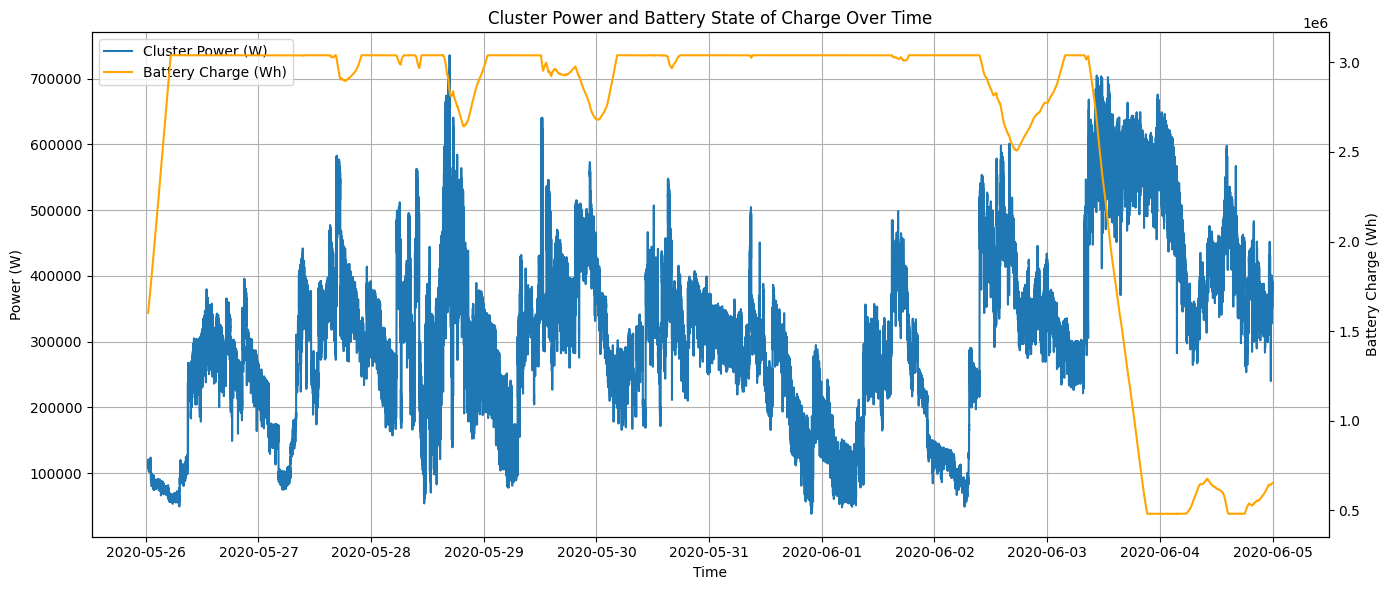

In [ ]:
# In questa simulazione ho una batteria, che viene utilizzata quando si supera il threshold
# e viene ricaricata quando si è sotto threshold.
# non si considera la fascia oraria nella gestione della batteria, tariife come su

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from utils.co2 import CarbonIntensityModels
from utils.battery_model import Battery
from utils.price_model import PriceModel


# ---------------------------
# PARAMETRI
# ---------------------------
THRESHOLD = 400000          # W
# list_thresholds = [300000,400000,500000]
BATTERY_CAPACITY = 3_200_000      # Wh
MAX_CHARGE_RATE = 3_200_000       # W
MAX_DISCHARGE_RATE = 3_200_000    # W

# INIZIALIZZO

battery = Battery(
    capacity_wh=BATTERY_CAPACITY,
    initial_charge_wh=BATTERY_CAPACITY / 2,
    max_charge_rate_w=MAX_CHARGE_RATE,
    max_discharge_rate_w=MAX_DISCHARGE_RATE,
)

total_cost = 0
total_co2 = 0

battery_history = []
time_history = []

df = pd.read_csv("csvs/cluster_power_only_nodes_10days.csv")#[8641:]
# df = pd.read_csv("cluster_power_only_nodes.csv")

df["time"] = pd.to_datetime(df["time"], utc=True)
df["dt_hours"] = df["time"].diff().dt.total_seconds() / 3600
df["dt_hours"] = df["dt_hours"].fillna(0)

price_model = PriceModel()
df["price_base"], df["price_high"] = price_model.prices_from_df(df)


# INSERISCO VALORI C02
cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
df["co2_intensity"] = cm.co2_from_csv(df)
# df["co2_intensity"] = cm.co2_fixed(df)

# df["energy_Wh"] = df["power"] * df["dt_hours"]

for idx, row in df.iterrows():

    COST_LOW = row["price_base"]
    COST_HIGH = row["price_high"]
    CO2_G_PER_KWH = row["co2_intensity"]

    power = row["power"]      # W
    dt = row["dt_hours"]      # h
    t = row["time"]

    if dt <= 0:
        continue

    E_base = min(power, THRESHOLD) * dt
    E_peak = max(power - THRESHOLD, 0) * dt

    # -----------------------------
    # CASO 1: sopra soglia → scarico
    # -----------------------------
    if power > THRESHOLD:

        # potenza richiesta alla batteria per coprire il picco
        P_discharge = min(
            power - THRESHOLD,
            MAX_DISCHARGE_RATE
        )

        # energia effettivamente fornita dalla batteria
        E_from_batt = battery.discharge(P_discharge, dt)

        # picco residuo
        E_peak_remaining = E_peak - E_from_batt

        cost = (
            E_base * COST_LOW +
            E_peak_remaining * COST_HIGH
        )

        co2_g = (
            (E_base + E_peak_remaining) / 1000
            * CO2_G_PER_KWH
        )

    # -----------------------------
    # CASO 2: sotto soglia → carico
    # -----------------------------
    else:

        # potenza disponibile prima della soglia
        P_available = THRESHOLD - power

        # potenza di carica
        P_charge = min(
            P_available,
            MAX_CHARGE_RATE
        )

        # energia effettivamente caricata
        E_charged = battery.charge(P_charge, dt)

        cost = (E_base + E_charged) * COST_LOW

        co2_g = (
            (E_base + E_charged) / 1000
            * CO2_G_PER_KWH
        )

    # dinamica lenta (OBBLIGATORIA)
    battery.step(dt)

    total_cost += cost
    total_co2 += co2_g

    battery_history.append(battery.energy)
    time_history.append(t)


# normalizzo
total_cost = total_cost 

print(f"Costo totale con batteria: {total_cost:.2f} €")
print(f"CO2 totale (kg): {total_co2 / 1000:.3f}")
print(f"Carica finale batteria: {battery.energy:.2f} Wh")
print(f"SOC finale: {battery.soc * 100:.2f} %")
print(f"Capacità residua: {battery.capacity:.0f} Wh")
fig, ax1 = plt.subplots(figsize=(14, 6))

# ---- Grafico della potenza (asse sinistro) ----
ax1.plot(df["time"], df["power"], label="Cluster Power (W)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Power (W)")
ax1.grid(True)

# ---- Asse destro per la carica della batteria ----
ax2 = ax1.twinx()
ax2.plot(time_history, battery_history, color="orange", label="Battery Charge (Wh)")
ax2.set_ylabel("Battery Charge (Wh)")

# ---- Titolo e legende ----
plt.title("Cluster Power and Battery State of Charge Over Time")

# Legende combinate
lns1, lbls1 = ax1.get_legend_handles_labels()
lns2, lbls2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, lbls1 + lbls2, loc="upper left")

plt.tight_layout()
plt.show()


In [ ]:
# In questa simulazione abbiamo la batteria che viene utilizzata come accumulatore di energie rinnoviabili.
# Vegnono unsate tutte le rinnovabili possibili e se ce n'è un eccesso, si ricarica l'accumulatore.
# se le rinnovabili non bastano, si usa prima la batteria e poi la rete elettrica.

# un modello di batteria più realistico è stato implementato.
# 
#


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from utils.renewable_real import RenewableModels
from utils.co2 import CarbonIntensityModels
from utils.carbonENTSOE import CarbonIntensityENTSOE
from utils.battery_model import Battery
from utils.price_model import PriceModel



## LOAD DATASET 
df = pd.read_csv("csvs/cluster_power_only_nodes_10days.csv") #[8641:]
# df = pd.read_csv("cluster_power_only_nodes.csv")

df["time"] = pd.to_datetime(df["time"], utc=True)
df["dt_hours"] = df["time"].diff().dt.total_seconds() / 3600
df["dt_hours"] = df["dt_hours"].fillna(0)

# INSERISCO PREZZI
price_model = PriceModel()
df["price_base"], df["price_high"] = price_model.prices_from_df(df)



# ---------------------------
# PARAMETRI
# ---------------------------

THRESHOLD = 400000          # W
BATTERY_CAPACITY = 3_200_000      # Wh

list_thresholds = [300000,400000,500000]
list_battery_capacity = [800_000, 1_600_000, 3_200_000,6_400_000]
list_renewables = [(200000,250000),(300000,350000),(400000,450000)]


results = []

for THRESHOLD in list_thresholds :
    for BATTERY_CAPACITY in list_battery_capacity:
        for p_max_ren in list_renewables:


            battery = Battery(
                capacity_wh=BATTERY_CAPACITY,
                initial_charge_wh=BATTERY_CAPACITY / 2,
                max_charge_rate_w=BATTERY_CAPACITY,
                max_discharge_rate_w=BATTERY_CAPACITY,
            )


            total_cost = 0
            total_co2_g = 0

            battery_history = []
            time_history = []
            curtailment_history = []
            cost_history = []
            co2_history_g = []



            # INSERISCO VALORI RINNOVABILI
            rm = RenewableModels()   # seed diverso per trainin
            #df["P_solar"] = rm.solar_cloudy2(df)
            #df["P_solar"] = rm.solar_simple(df)
            #df["P_wind"] = rm.wind_stochastic(df)
            #df["P_wind"] = rm.wind_uniform(df)
            df["P_wind"] = rm.wind_from_openmeteo(df, p_max_ren[0])
            df["P_solar"] = rm.solar_from_openmeteo(df, p_max_ren[1])
            df["P_ren"]   = df["P_solar"] + df["P_wind"]

            # INSERISCO VALORI C02
            cm = CarbonIntensityModels(csv_file="csvs/carbon_intensity_IT-NORTH-2020.csv")
            df["co2_intensity"] = cm.co2_from_csv(df)
            # df["co2_intensity"] = cm.co2_fixed(df)


            # cm =CarbonIntensityENTSOE(api_key="---")
            # df["co2_intensity"] = cm.co2_from_entsoe(df)

            # df["energy_Wh"] = df["power"] * df["dt_hours"]

            # ASSUNZIONE: MAX_CHARGE_RATE, MAX_DISCHARGE_RATE in W; BATTERY_* in Wh; dt in hours
            # THRESHOLD in W si applica alla POTENZA presa dalla rete (P_grid)

            for idx, row in df.iterrows():
                COST_LOW = row["price_base"]
                COST_HIGH = row["price_high"]
                
                CO2_G_PER_KWH = row["co2_intensity"]

                P_load = row["power"]        # W, carico del cluster
                P_ren  = row["P_ren"]        # W, rinnovabili disponibili
                dt = row["dt_hours"]         # ore
                t = row["time"]

                # 1) uso rinnovabili per coprire il carico (in potenza)
                P_from_ren = min(P_load, P_ren)          # W usati immediatamente
                P_excess_ren = max(P_ren - P_from_ren, 0) # W in eccesso che possono caricare la batteria

                # 1a) se c'è eccesso, carico la batteria (convertire in energia Wh)
                if P_excess_ren > 0:
                    E_excess_available = P_excess_ren * dt

                    E_charged = battery.charge(P_excess_ren, dt)
                    E_curtail = E_excess_available - E_charged

                    curtailment_history.append(E_curtail)
                    total_cost += 0
                    total_co2_g += 0

                    battery.step(dt)

                    battery_history.append(battery.energy)
                    time_history.append(t)
                    cost_history.append(0)
                    co2_history_g.append(0)
                    continue

                # 2) se qui, P_ren <= P_load -> ci sono rinnovabili ma non sufficienti
                # restante potenza da coprire (W)
                P_remaining = P_load - P_from_ren   # W

                # converti a energia per confronto con batteria (Wh)
                E_needed = P_remaining * dt

                E_from_batt = battery.discharge(P_remaining, dt)
                E_needed_after_batt = E_needed - E_from_batt

                # calcolo import dalla rete in POTENZA per applicare THRESHOLD
                P_grid_import = E_needed_after_batt / dt if dt > 0 else 0  # W

                # separa base/peak sull'energia presa dalla rete
                # Applichiamo THRESHOLD alla potenza importata dalla rete (come richiesto)
                E_base = min(P_grid_import, THRESHOLD) * dt
                E_peak = max(P_grid_import - THRESHOLD, 0) * dt

                # costi
                cost = E_base * COST_LOW + E_peak * COST_HIGH
                total_cost += cost
                cost_history.append(cost)

                # co2
                co2_g = (E_base + E_peak) / 1000 * CO2_G_PER_KWH
                total_co2_g += co2_g
                
                co2_history_g.append(co2_g)


                # curtailment zero in questo ramo (nessun eccesso)
                curtailment_history.append(0)

                # storico
                battery_history.append(battery.energy)
                time_history.append(t)

                #
                battery.step(dt)


            info = battery.info()
            # print("PARAMETRI ESPERIMENTO:")
            # print(f"Threshold = {THRESHOLD}")
            # print(f"Battery capacity = {BATTERY_CAPACITY}")
            # print(f"Pmax WInd = {p_max_ren[0]}",f"Pmax Sun = {p_max_ren[1]}")
            # print("RISULTATI:")
            # print(f"Costo totale con batteria: {total_cost:.2f} €")
            # print(f"CO2 totale (kg): {total_co2_g/1000:.3f}")
            
            # print(f"Carica finale batteria: {info['energy_Wh']:.2f} Wh")
            # print(f"SOC finale: {info['SOC']:.2%}")
            # print(f"Capacità residua: {info['capacity_Wh']:.0f} Wh")
            # print("--------------------------------------------------------")
            # print("--------------------------------------------------------")
            results.append({
                "threshold": THRESHOLD,
                "battery_capacity": BATTERY_CAPACITY,
                "pmaxwind": p_max_ren[0],
                "pmaxsun": p_max_ren[1],
                "costo_euro": total_cost,
                "co2_kg": total_co2_g / 1000,
                "SOC_finale": info["SOC"],
            })

# salvo i results su file
pd.DataFrame(results).to_csv("outputSim/results.csv", index=False)

fig, ax1 = plt.subplots(figsize=(14, 6))
# ---- Grafico della potenza (asse sinistro) ----
ax1.plot(df["time"], df["power"], label="Cluster Power (W)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Power (W)")
ax1.grid(True)

# ---- Asse destro per la carica della batteria ----
ax2 = ax1.twinx()
ax2.plot(time_history, battery_history, color="orange", label="Battery Charge (Wh)")
ax2.set_ylabel("Battery Charge (Wh)")

# ---- Titolo e legende ----
plt.title("Cluster Power and Battery State of Charge Over Time")

# Legende combinate
lns1, lbls1 = ax1.get_legend_handles_labels()
lns2, lbls2 = ax2.get_legend_handles_labels()
ax1.legend(lns1 + lns2, lbls1 + lbls2, loc="upper left")

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_history, df["co2_intensity"])
plt.xlabel("Time")
plt.ylabel("co2 intensty ")
plt.title("Co2 intensity north italy trend")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_history, df["P_ren"])
plt.xlabel("Time")
plt.ylabel("ren Energy")
plt.title("cRenewable energy")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_history, co2_history_g)
plt.xlabel("Time")
plt.ylabel("co2 emission")
plt.title("Co2 emission history")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(time_history, cost_history)
plt.xlabel("Time")
plt.ylabel("costs")
plt.title("cost history")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# test saved model

obs, _ = env.reset()
done = False
total_cost_rl = 0

while not done:
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    total_cost_rl += -reward

print("Costo totale RL:", total_cost_rl)

Costo totale RL: 8947.275138879231
